In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
fact_disease=pd.read_csv(r"C:\Users\attil\Downloads\fact_disease_surveillance.csv")
dim_date=pd.read_csv(r"C:\Users\attil\Downloads\dim_date.csv")

In [11]:
dim_date.head()

,date_id,full_date,year,month_num,month_name,quarter,year_month
0,1,2022-01-01,2022,1,January,Q1,2022-01
1,2,2022-02-01,2022,2,February,Q1,2022-02
2,3,2022-03-01,2022,3,March,Q1,2022-03
3,4,2022-04-01,2022,4,April,Q2,2022-04
4,5,2022-05-01,2022,5,May,Q2,2022-05


In [12]:
fact_disease.head()

,fact_id,date_id,state_id,disease_id,source_id,population_under_surveillance,total_reported_cases,active_cases,recovered_cases,deaths,urban_cases,rural_cases,hospitalized_cases,icu_admissions,case_fatality_rate,recovery_rate,public_health_risk_score,report_date_raw
0,1,1,1,1,6,46850798,2091,139,1889.0,63.0,1368,723,143.0,42.0,3.01,90.34,31.3,2022-01-01
1,2,1,1,2,6,46330962,2357,180,2101.0,76.0,1039,1318,505.0,81.0,3.22,89.14,32.1,2022-01-01
2,3,1,1,3,2,49588439,2936,427,2430.0,79.0,1941,995,716.0,195.0,2.69,82.77,32.3,2022-01-01
3,4,1,1,4,1,47346875,335,21,306.0,8.0,166,169,81.0,10.0,2.39,91.34,10.0,2022-01-01
4,5,1,1,5,5,52543820,310,30,NaN,2.0,195,115,42.0,10.0,0.65,89.68,2.9,01-01-2022


In [13]:
merged=fact_disease.merge(
    dim_date,
    on="date_id",
    how="left"
)

### Monthly trends

In [14]:
monthly=(
    merged.groupby("year_month")['total_reported_cases']
    .sum()
    .reset_index()
)

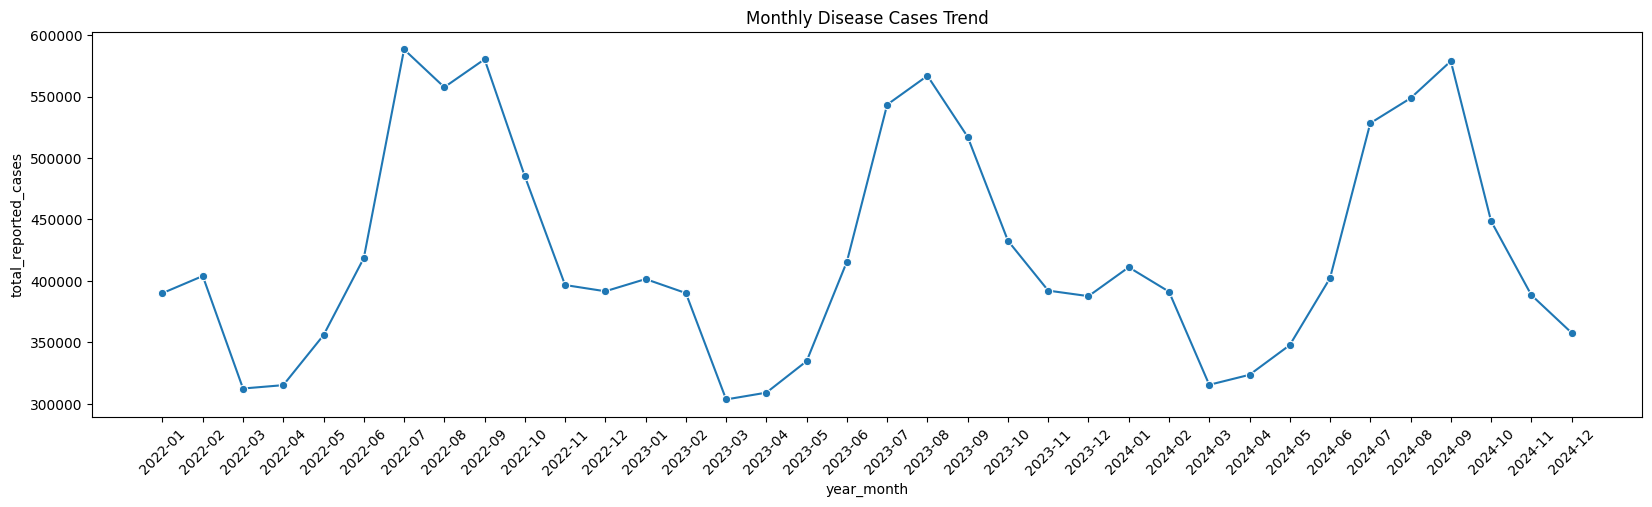

In [18]:
plt.figure(figsize=(20,5))
sns.lineplot(
    data=monthly,
    x="year_month",
    y="total_reported_cases",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Disease Cases Trend")

plt.show()

### Yearly Trend

In [19]:
yearly = (
merged.groupby("year")
["total_reported_cases"]
.sum()
.reset_index()
)

<Axes: xlabel='year', ylabel='total_reported_cases'>

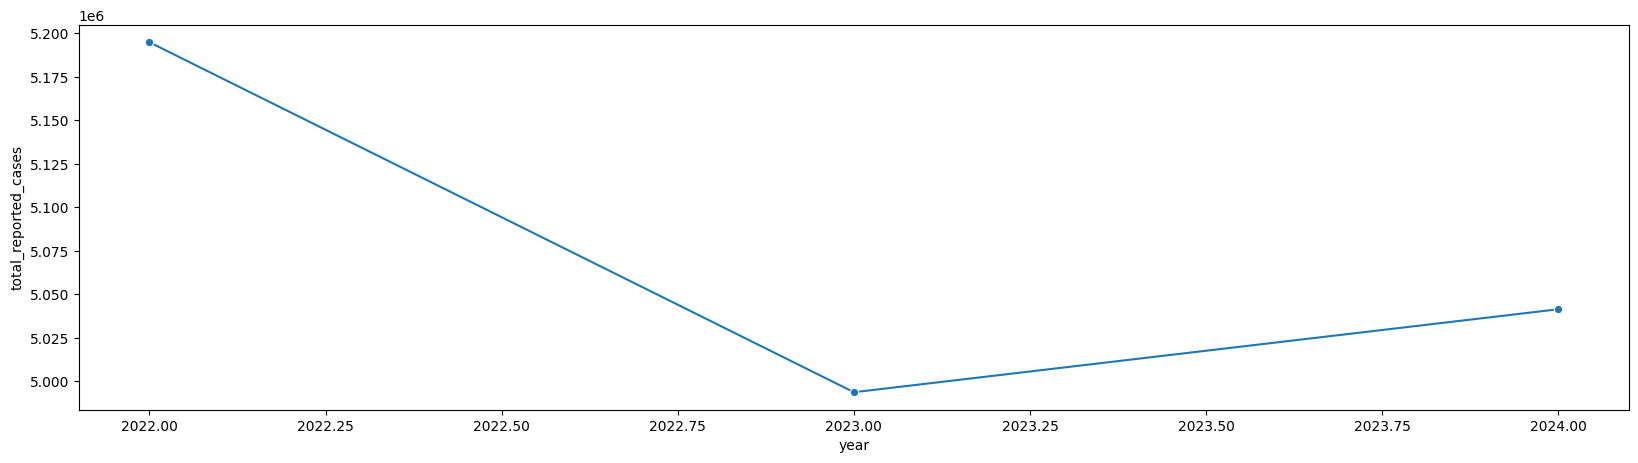

In [21]:
plt.figure(figsize=(20,5))

sns.lineplot(
data=yearly,
x="year",
y="total_reported_cases",
marker="o"
)

### Quarterly Trend

In [22]:
quarterly = (
merged.groupby(
["year","quarter"]
)
["total_reported_cases"]
.sum()
.reset_index()
)

<Axes: xlabel='quarter', ylabel='total_reported_cases'>

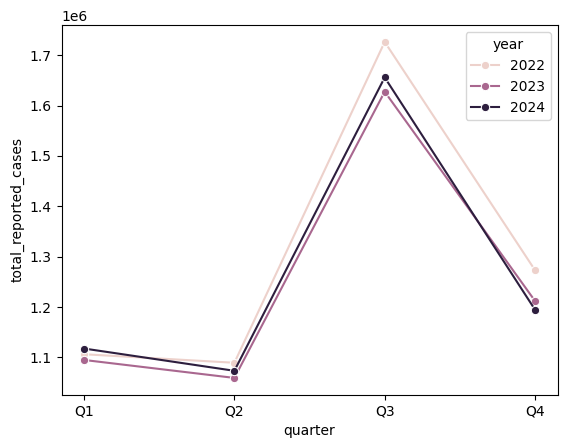

In [23]:
sns.lineplot(
data=quarterly,
x="quarter",
y="total_reported_cases",
hue="year",
marker="o"
)

### Seasonal Analysis

In [27]:
season_map = {
    "December": "Winter",
    "January": "Winter",
    "February": "Winter",
    "March": "Summer",
    "April": "Summer",
    "May": "Summer",
    "June": "Monsoon",
    "July": "Monsoon",
    "August": "Monsoon",
    "September": "Monsoon",
    "October": "Post-Monsoon",
    "November": "Post-Monsoon"
}

merged["season"] = merged["month_name"].map(season_map)

In [28]:
season_cases = (
    merged.groupby("season")["total_reported_cases"]
    .sum()
    .reset_index()
)

<Axes: xlabel='season', ylabel='total_reported_cases'>

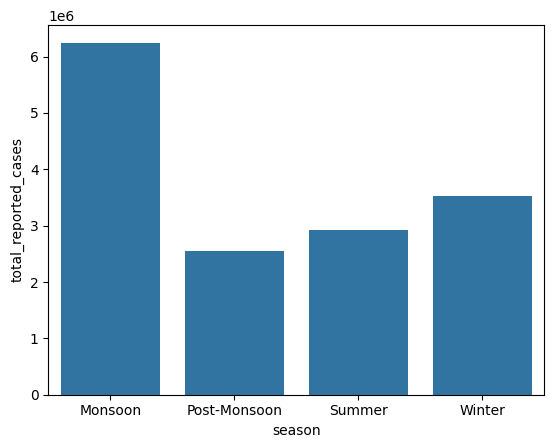

In [29]:
sns.barplot(
    data=season_cases,
    x="season",
    y="total_reported_cases"
)

### Rolling Average

In [31]:
monthly["Rolling_Avg"] = (
    monthly["total_reported_cases"]
    .rolling(window=3)
    .mean()
)

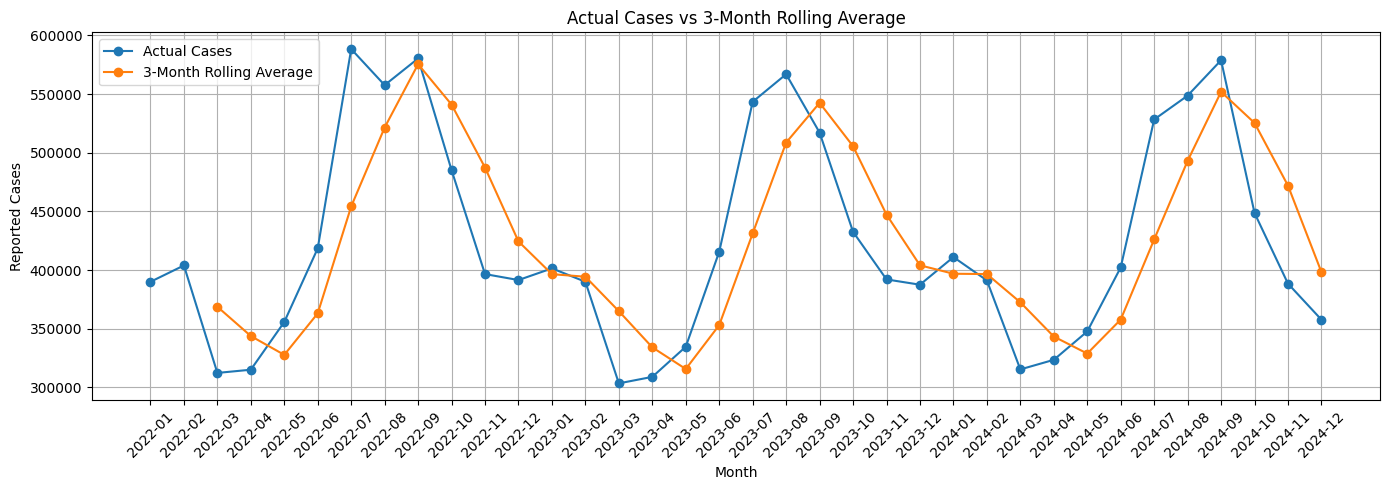

In [34]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly["year_month"],
    monthly["total_reported_cases"],
    marker="o",
    label="Actual Cases"
)

plt.plot(
    monthly["year_month"],
    monthly["Rolling_Avg"],
    marker="o",
    label="3-Month Rolling Average"
)

plt.xticks(rotation=45)

plt.title("Actual Cases vs 3-Month Rolling Average")

plt.xlabel("Month")

plt.ylabel("Reported Cases")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

### Month-over-Month growth

In [35]:
monthly["Growth"] = (
monthly["total_reported_cases"]
.pct_change()*100
)

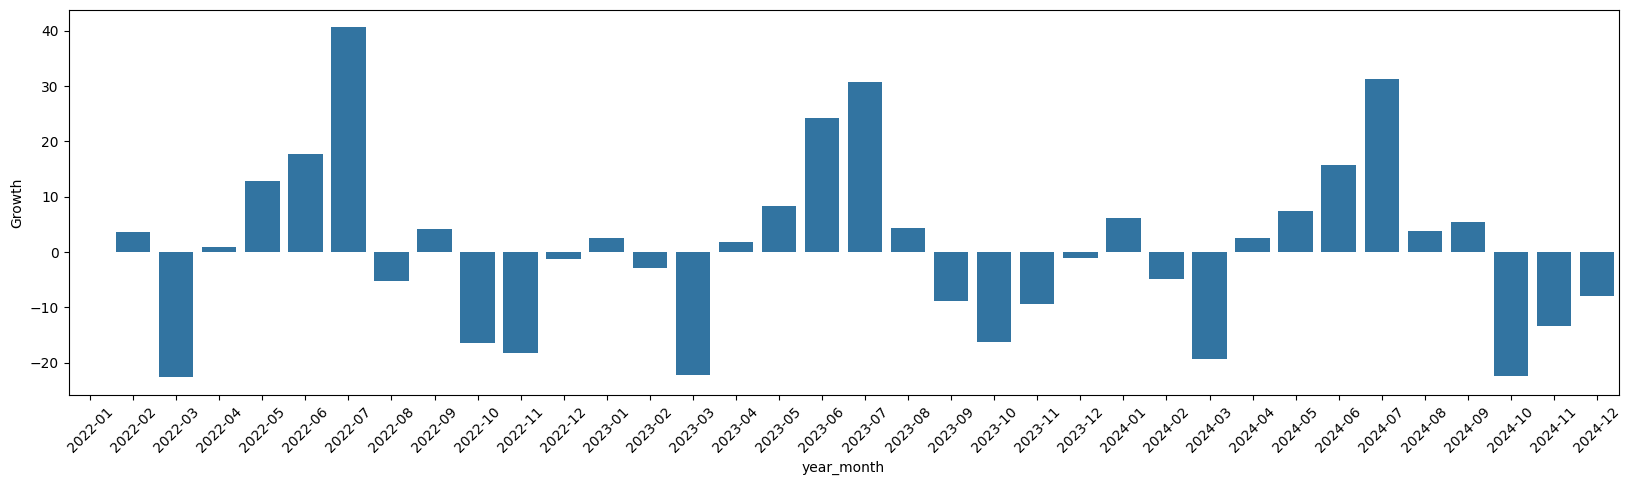

In [39]:
plt.figure(figsize=(20,5))
sns.barplot(
data=monthly,
x="year_month",
y="Growth"
)
plt.xticks(rotation=45)
plt.show()

### Month-Year Heatmap

In [40]:
heat = (
merged.groupby(
[
"year",
"month_name"
]
)
["total_reported_cases"]
.sum()
.reset_index()
)

In [41]:
pivot = heat.pivot(
index="month_name",
columns="year",
values="total_reported_cases"
)

<Axes: xlabel='year', ylabel='month_name'>

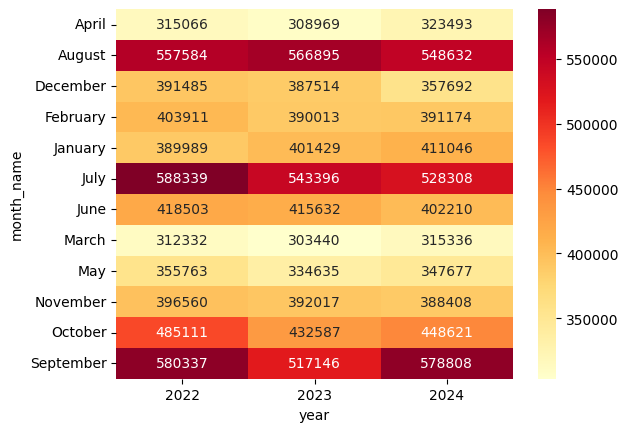

In [42]:
sns.heatmap(
pivot,
annot=True,
cmap="YlOrRd",
fmt=".0f"
)